# Stage 3 — ANN Model Refinement, Evaluation & Insight Reporting
### Customer Churn Analysis for Advanced Telecommunications Solutions (ATS)

**Project role:** Data Analyst — Predictive Modeling
**Programme:** ACS Professional Year — Data Analyst (WIL) Project

---

**Stage 3 activities for this role** (source: `DA_Will_Program.docx`, Activity Breakdown table, Stage 3 column):

1. Evaluate the ANN model's predictive performance and refine the model based on feedback or findings.
2. Interpret the results, identifying key factors influencing customer churn.
3. Document and visualise the findings for team discussions and presentations.
4. Communicate predictive insights to other team members for the final project report.
5. Provide insights on predictive accuracy and recommendations for further actions.

**Data used** — the Stage 2 Data Engineer hand-off (`Stage2_Data_Preparation_Report.docx` §7, `README.txt`):

| File | Role in this notebook |
|---|---|
| `train_set.csv` | 5,392 rows — scaled training data (model fitting, validation, cross-validation) |
| `test_set.csv` | 1,349 rows — scaled held-out test data, used **only** for the final evaluation |
| `train_set_unscaled.csv` | Original units — customer segmentation |
| `test_set_unscaled.csv` | Original units — business interpretation of the drivers |

Scaling was fitted on the training set only in Stage 2, so the test set remains genuinely unseen.

**Approximate run time:** 8–12 minutes on a standard Colab CPU runtime (no GPU required).

---
## Section 1 — Environment Setup

In [1]:
# Google Colab already ships with these libraries. This cell only installs
# anything that happens to be missing, so the notebook runs anywhere.
import importlib, subprocess, sys

for pkg, mod in [("tensorflow", "tensorflow"), ("scikit-learn", "sklearn"),
                 ("pandas", "pandas"), ("numpy", "numpy"),
                 ("matplotlib", "matplotlib"), ("seaborn", "seaborn")]:
    if importlib.util.find_spec(mod) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

print("Environment check complete.")

Environment check complete.


In [2]:
# ---- Core libraries -------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ---- TensorFlow / Keras ---------------------------------------------------
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ---- scikit-learn ---------------------------------------------------------
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix,
                             classification_report, brier_score_loss)

# ---- Reproducibility ------------------------------------------------------
SEED = 42
keras.utils.set_random_seed(SEED)     # seeds python, numpy and tensorflow together
np.random.seed(SEED)

# ---- Plot styling (clean and minimal) -------------------------------------
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10, "axes.titleweight": "bold",
})
BLUE, RED, GREEN, GREY = "#1565C0", "#C62828", "#2E7D32", "#757575"

print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")
print(f"pandas     : {pd.__version__}")
print(f"Random seed: {SEED}")

I0000 00:00:1786212058.124864    7071 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786212058.406424    7071 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786212061.067042    7071 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow : 2.21.0
Keras      : 3.15.1
pandas     : 3.0.2
Random seed: 42


---
## Section 2 — Load the Stage 2 Datasets

The four Stage 2 hand-off files are loaded. In Google Colab, if the files are not already in the
session, an upload prompt appears.

In [3]:
REQUIRED_FILES = ["train_set.csv", "test_set.csv",
                  "train_set_unscaled.csv", "test_set_unscaled.csv"]

def in_colab():
    return importlib.util.find_spec("google.colab") is not None

def locate(fname):
    """Find a data file in the usual Colab / local locations."""
    for folder in ["", "/content/", "/content/data/", "data/",
                   "/content/drive/MyDrive/", "/content/drive/MyDrive/Stage3/"]:
        path = os.path.join(folder, fname)
        if os.path.exists(path):
            return path
    return None

missing = [f for f in REQUIRED_FILES if locate(f) is None]

if missing and in_colab():
    from google.colab import files
    print("Please upload these Stage 2 files:", ", ".join(missing))
    files.upload()
    missing = [f for f in REQUIRED_FILES if locate(f) is None]

if missing:
    raise FileNotFoundError(f"Still missing: {missing}. Place them next to this notebook.")

train_df          = pd.read_csv(locate("train_set.csv"))
test_df           = pd.read_csv(locate("test_set.csv"))
train_unscaled_df = pd.read_csv(locate("train_set_unscaled.csv"))
test_unscaled_df  = pd.read_csv(locate("test_set_unscaled.csv"))

print(f"train_set.csv          : {train_df.shape[0]:,} rows x {train_df.shape[1]} columns")
print(f"test_set.csv           : {test_df.shape[0]:,} rows x {test_df.shape[1]} columns")
print(f"train_set_unscaled.csv : {train_unscaled_df.shape[0]:,} rows")
print(f"test_set_unscaled.csv  : {test_unscaled_df.shape[0]:,} rows")
train_df.head()

train_set.csv          : 5,392 rows x 21 columns
test_set.csv           : 1,349 rows x 21 columns
train_set_unscaled.csv : 5,392 rows
test_set_unscaled.csv  : 1,349 rows


,SeniorCitizen,tenure,MonthlyCharges,gender_encoded,Dependents_encoded,PhoneService_encoded,MultipleLines_encoded,Churn_encoded,InternetService_DSL,InternetService_Fiber optic,...,Contract_One year,Contract_Two year,EstimatedTotalCharges,ContractLengthMonths,ServiceCount,IsNewCustomer,TenureGroup_New (0-12mo),TenureGroup_Established (13-24mo),TenureGroup_Loyal (25-48mo),TenureGroup_Very Loyal (49-72mo)
0,0,0.944773,1.486201,0,1,1,1,0,False,True,...,False,False,1.689806,-0.846893,1.153727,0,False,False,False,True
1,0,1.232687,-0.234838,0,0,1,0,0,True,False,...,False,False,0.609018,-0.846893,-0.546901,0,False,False,False,True
2,0,0.821382,0.946267,0,0,1,0,0,True,False,...,True,False,1.168657,0.294485,-0.546901,0,False,False,False,True
3,0,1.602861,1.621184,1,1,1,0,0,True,False,...,False,False,2.595844,-0.846893,-0.546901,0,False,False,False,True
4,0,-0.988360,0.338842,1,0,1,0,0,True,False,...,False,False,-0.732786,-0.846893,-0.546901,0,True,False,False,False


In [4]:
# ---- Data integrity check before any modelling ----------------------------
TARGET = "Churn_encoded"
SCALED_NUMERIC = ["tenure", "MonthlyCharges", "EstimatedTotalCharges",
                  "ContractLengthMonths", "ServiceCount"]

integrity = pd.DataFrame([
    {"Check": "Rows",                  "Training set": f"{len(train_df):,}",
     "Test set": f"{len(test_df):,}"},
    {"Check": "Columns",               "Training set": train_df.shape[1],
     "Test set": test_df.shape[1]},
    {"Check": "Missing values",        "Training set": int(train_df.isnull().sum().sum()),
     "Test set": int(test_df.isnull().sum().sum())},
    {"Check": "Churn rate",            "Training set": f"{train_df[TARGET].mean()*100:.2f}%",
     "Test set": f"{test_df[TARGET].mean()*100:.2f}%"},
    {"Check": "Scaled cols mean (~0)", "Training set": f"{train_df[SCALED_NUMERIC].mean().mean():.4f}",
     "Test set": f"{test_df[SCALED_NUMERIC].mean().mean():.4f}"},
    {"Check": "Scaled cols std (~1)",  "Training set": f"{train_df[SCALED_NUMERIC].std().mean():.4f}",
     "Test set": f"{test_df[SCALED_NUMERIC].std().mean():.4f}"},
])

print("Table 2.1 - Stage 2 data integrity verification")
display(integrity)

# The test-set means are near (but not exactly) 0 because the scaler was fitted on the
# training set only - this is the expected, leakage-free behaviour.

Table 2.1 - Stage 2 data integrity verification


,Check,Training set,Test set
0,Rows,"5,392","1,349"
1,Columns,21,21
2,Missing values,0,0
3,Churn rate,26.58%,26.54%
4,Scaled cols mean (~0),-0.0000,-0.0280
5,Scaled cols std (~1),1.0001,0.9886


---
## Section 3 — The Stage 2 Baseline to Improve On

These figures are already documented in `Stage2_CustomerChurn_ANN_Report.docx` (Section 8). They
came from a different split (70/15/15 on the Stage 1 file, 11 features, test n = 1,012), so they are
the **reference point**, not a like-for-like comparison. A like-for-like baseline is retrained on
the Stage 2 split in Section 5 and compared properly in Section 9.

In [5]:
STAGE2_RECORDED = {"Accuracy": 0.7085, "Precision": 0.4677, "Recall": 0.6989,
                   "F1-Score": 0.5604, "ROC-AUC": 0.7852}

print("Table 3.1 - Stage 2 ANN results as documented (test n = 1,012, 11 features)")
display(pd.DataFrame(STAGE2_RECORDED.items(), columns=["Metric", "Stage 2 recorded value"]))

Table 3.1 - Stage 2 ANN results as documented (test n = 1,012, 11 features)


,Metric,Stage 2 recorded value
0,Accuracy,0.7085
1,Precision,0.4677
2,Recall,0.6989
3,F1-Score,0.5604
4,ROC-AUC,0.7852


---
## Section 4 — Feature Sets, Model Builder and Evaluation Helpers

Three candidate feature sets are compared during refinement:

* **Stage-1 set** — the 12 encoded columns equivalent to what the Stage 2 ANN used, with no
  engineered features. This is the like-for-like baseline.
* **Full Stage-2 set** — all 20 columns from the Stage 2 hand-off, including the five engineered
  features (`EstimatedTotalCharges`, `ContractLengthMonths`, `ServiceCount`, `IsNewCustomer`,
  `TenureGroup_*`).
* **Reduced set** — the full set minus `gender_encoded`, `PhoneService_encoded` and
  `MultipleLines_encoded`, which the Stage 2 Data Preparation Report found to have **no significant
  statistical relationship with churn** (chi-square p = 0.349, 0.258 and 0.590). Testing this set is
  the "refine based on the team's findings" step required by the programme.

In [6]:
ALL_FEATURES = [c for c in train_df.columns if c != TARGET]

STAGE1_FEATURES = ["gender_encoded", "SeniorCitizen", "Dependents_encoded", "tenure",
                   "PhoneService_encoded", "MultipleLines_encoded",
                   "InternetService_DSL", "InternetService_Fiber optic", "MonthlyCharges",
                   "Contract_Month-to-month", "Contract_One year", "Contract_Two year"]

NON_SIGNIFICANT = ["gender_encoded", "PhoneService_encoded", "MultipleLines_encoded"]
REDUCED_FEATURES = [c for c in ALL_FEATURES if c not in NON_SIGNIFICANT]

FEATURE_SETS = {"Stage-1 set": STAGE1_FEATURES,
                "Full Stage-2 set": ALL_FEATURES,
                "Reduced set": REDUCED_FEATURES}

for name, cols in FEATURE_SETS.items():
    print(f"{name:<18}: {len(cols)} features")

y_train_full = train_df[TARGET].astype(int).to_numpy()
y_test       = test_df[TARGET].astype(int).to_numpy()

def make_matrix(df, cols):
    """Return a float numpy matrix (boolean one-hot columns become 0.0/1.0)."""
    return df[cols].astype(float).to_numpy()

Stage-1 set       : 12 features
Full Stage-2 set  : 20 features
Reduced set       : 17 features


In [7]:
# ---- Internal validation split (taken from the training set only) ----------
# The test set is never used for any model selection decision.
train_idx, val_idx = train_test_split(
    np.arange(len(train_df)), test_size=0.15, stratify=y_train_full, random_state=SEED)

y_tr, y_val = y_train_full[train_idx], y_train_full[val_idx]

print(f"Model-fitting rows : {len(train_idx):,} (churn {y_tr.mean()*100:.1f}%)")
print(f"Validation rows    : {len(val_idx):,} (churn {y_val.mean()*100:.1f}%)")
print(f"Held-out test rows : {len(test_df):,} (churn {y_test.mean()*100:.1f}%)")

# ---- Class weights: churn is only about 26.6% of customers ----------------
def get_class_weights(y):
    w = compute_class_weight("balanced", classes=np.array([0, 1]), y=y)
    return {0: float(w[0]), 1: float(w[1])}

CLASS_WEIGHT = get_class_weights(y_tr)
print(f"\nClass weights      : No Churn {CLASS_WEIGHT[0]:.3f} | Churn {CLASS_WEIGHT[1]:.3f}")

Model-fitting rows : 4,583 (churn 26.6%)
Validation rows    : 809 (churn 26.6%)
Held-out test rows : 1,349 (churn 26.5%)

Class weights      : No Churn 0.681 | Churn 1.881


In [8]:
def build_ann(input_dim, units=(64, 32, 16), dropout=(0.3, 0.2, 0.0),
              lr=0.001, l2reg=0.001, seed=SEED):
    """Feed-forward ANN for binary churn classification.

    Same design family as the Stage 2 model: Dense + ReLU + BatchNorm + Dropout + L2,
    with one sigmoid output that returns a churn probability between 0 and 1.
    """
    keras.utils.set_random_seed(seed)
    model = keras.Sequential(name="ANN_Churn")
    model.add(keras.Input(shape=(input_dim,)))
    for i, (n, d) in enumerate(zip(units, dropout), start=1):
        model.add(layers.Dense(n, activation="relu",
                               kernel_regularizer=keras.regularizers.l2(l2reg),
                               kernel_initializer="he_normal", name=f"hidden_{i}"))
        model.add(layers.BatchNormalization(name=f"batchnorm_{i}"))
        if d > 0:
            model.add(layers.Dropout(d, name=f"dropout_{i}"))
    model.add(layers.Dense(1, activation="sigmoid", name="output"))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss="binary_crossentropy",
                  metrics=["accuracy", keras.metrics.AUC(name="auc")])
    return model


def fit_model(model, Xtr, ytr, Xval, yval, class_weight=None,
              epochs=120, patience=15, batch_size=64, verbose=0):
    """Train with early stopping on validation AUC and learning-rate reduction."""
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=patience,
                                      restore_best_weights=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8,
                                          min_lr=1e-6, verbose=0),
    ]
    return model.fit(Xtr, ytr, validation_data=(Xval, yval), epochs=epochs,
                     batch_size=batch_size,
                     class_weight=class_weight if class_weight else CLASS_WEIGHT,
                     callbacks=callbacks, verbose=verbose)


def evaluate(y_true, proba, threshold=0.5):
    """Standard classification metrics at a given decision threshold."""
    pred = (proba >= threshold).astype(int)
    return {"Accuracy":  accuracy_score(y_true, pred),
            "Precision": precision_score(y_true, pred, zero_division=0),
            "Recall":    recall_score(y_true, pred, zero_division=0),
            "F1-Score":  f1_score(y_true, pred, zero_division=0),
            "ROC-AUC":   roc_auc_score(y_true, proba),
            "PR-AUC":    average_precision_score(y_true, proba)}


def best_f1_threshold(y_true, proba):
    """Decision threshold that maximises F1 on the given set."""
    grid = np.arange(0.05, 0.96, 0.01)
    scores = [f1_score(y_true, (proba >= t).astype(int), zero_division=0) for t in grid]
    return float(grid[int(np.argmax(scores))]), float(np.max(scores))


def ensemble_proba(models, X):
    """Average the predicted probabilities of several trained models."""
    return np.mean([m.predict(X, verbose=0).ravel() for m in models], axis=0)

print("Model builder, training and evaluation helpers defined.")

Model builder, training and evaluation helpers defined.


---
## Section 5 — Refinement Experiments

Five configurations are compared. Two things vary: which features go in, and how the network is
shaped.

**One important precaution.** A neural network gives slightly different results every time it is
trained, purely because of the random starting weights. Comparing configurations on a single
training run would risk picking a winner by luck. Each configuration is therefore trained with
**three different random seeds** and scored by its *average* validation performance.

**Selection rule (fixed before looking at any result):** rank by mean validation ROC-AUC; where
configurations fall within one standard deviation of the leader — that is, they are statistically
indistinguishable — prefer the one with the higher validation F1, because identifying churners is
the business objective. The test set plays no part in this.

In [9]:
EXPERIMENTS = [
    # name, feature set, hidden units, dropout, learning rate
    ("A. Stage 2 baseline (rebuilt)", "Stage-1 set",      (64, 32, 16),  (0.3, 0.2, 0.0), 0.001),
    ("B. Full features, same shape",  "Full Stage-2 set", (64, 32, 16),  (0.3, 0.2, 0.0), 0.001),
    ("C. Full features, smaller net", "Full Stage-2 set", (32, 16),      (0.2, 0.1),      0.001),
    ("D. Full features, wider net",   "Full Stage-2 set", (128, 64, 32), (0.4, 0.3, 0.2), 0.0005),
    ("E. Reduced features",           "Reduced set",      (64, 32, 16),  (0.3, 0.2, 0.0), 0.001),
]

SEEDS_EXPERIMENT = [42, 7, 101]
results, trained_models = [], {}

for name, fs_name, units, dropout, lr in EXPERIMENTS:
    cols  = FEATURE_SETS[fs_name]
    X_all = make_matrix(train_df, cols)
    Xtr, Xval = X_all[train_idx], X_all[val_idx]

    aucs, f1s, epochs_run, models = [], [], [], []
    for s in SEEDS_EXPERIMENT:
        model = build_ann(Xtr.shape[1], units=units, dropout=dropout, lr=lr, seed=s)
        hist  = fit_model(model, Xtr, y_tr, Xval, y_val, epochs=120, patience=15)
        proba = model.predict(Xval, verbose=0).ravel()
        aucs.append(roc_auc_score(y_val, proba))
        f1s.append(best_f1_threshold(y_val, proba)[1])
        epochs_run.append(len(hist.history["loss"]))
        models.append(model)

    trained_models[name] = {"models": models, "cols": cols, "units": units,
                            "dropout": dropout, "lr": lr, "feature_set": fs_name}
    results.append({"Configuration": name, "Feature set": fs_name, "Features": len(cols),
                    "Hidden layers": " - ".join(map(str, units)), "LR": lr,
                    "Mean epochs": int(np.mean(epochs_run)),
                    "Val ROC-AUC (mean)": round(float(np.mean(aucs)), 4),
                    "Val ROC-AUC (std)":  round(float(np.std(aucs)), 4),
                    "Val F1 (mean)":      round(float(np.mean(f1s)), 4)})
    print(f"{name:<32} Val AUC {np.mean(aucs):.4f} +/- {np.std(aucs):.4f} "
          f"| Val F1 {np.mean(f1s):.4f}")

exp_df = pd.DataFrame(results)
print("\nTable 5.1 - Refinement experiments, averaged over 3 random seeds (validation set)")
display(exp_df)

A. Stage 2 baseline (rebuilt)    Val AUC 0.8152 +/- 0.0009 | Val F1 0.6107


B. Full features, same shape     Val AUC 0.8142 +/- 0.0035 | Val F1 0.6193


C. Full features, smaller net    Val AUC 0.8158 +/- 0.0050 | Val F1 0.6160


D. Full features, wider net      Val AUC 0.8160 +/- 0.0028 | Val F1 0.6169


E. Reduced features              Val AUC 0.8144 +/- 0.0016 | Val F1 0.6120

Table 5.1 - Refinement experiments, averaged over 3 random seeds (validation set)


,Configuration,Feature set,Features,Hidden layers,LR,Mean epochs,Val ROC-AUC (mean),Val ROC-AUC (std),Val F1 (mean)
0,A. Stage 2 baseline (rebuilt),Stage-1 set,12,64 - 32 - 16,0.0010,32,0.8152,0.0009,0.6107
1,"B. Full features, same shape",Full Stage-2 set,20,64 - 32 - 16,0.0010,48,0.8142,0.0035,0.6193
2,"C. Full features, smaller net",Full Stage-2 set,20,32 - 16,0.0010,48,0.8158,0.0050,0.6160
3,"D. Full features, wider net",Full Stage-2 set,20,128 - 64 - 32,0.0005,63,0.8160,0.0028,0.6169
4,E. Reduced features,Reduced set,17,64 - 32 - 16,0.0010,38,0.8144,0.0016,0.6120


Highest mean validation ROC-AUC : D. Full features, wider net (0.8160)
Within one std (0.0028)  : 5 configuration(s) - statistically indistinguishable on AUC
Tie broken on validation F1     : B. Full features, same shape


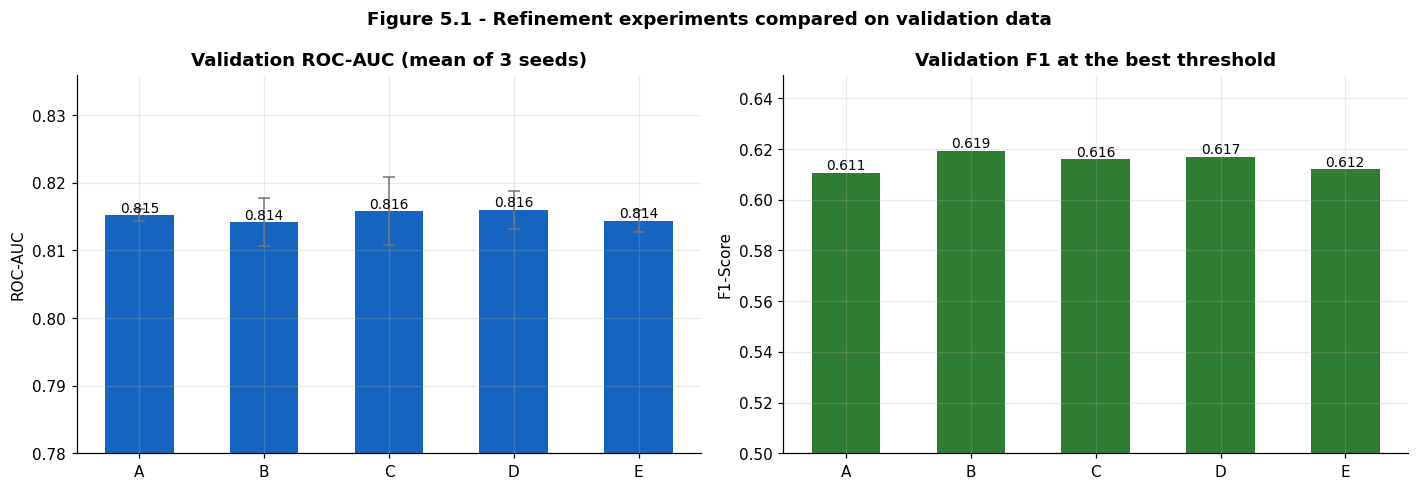


The error bars overlap: the network architecture is not the limiting factor here - the information available in the data is.


In [10]:
# ---- Apply the selection rule ---------------------------------------------
leader    = exp_df.loc[exp_df["Val ROC-AUC (mean)"].idxmax()]
tolerance = float(leader["Val ROC-AUC (std)"])
tied      = exp_df[exp_df["Val ROC-AUC (mean)"] >= leader["Val ROC-AUC (mean)"] - tolerance]

BEST_NAME = tied.loc[tied["Val F1 (mean)"].idxmax(), "Configuration"]
BASE_NAME = "A. Stage 2 baseline (rebuilt)"

print(f"Highest mean validation ROC-AUC : {leader['Configuration']} "
      f"({leader['Val ROC-AUC (mean)']:.4f})")
print(f"Within one std ({tolerance:.4f})  : {len(tied)} configuration(s) - "
      f"statistically indistinguishable on AUC")
print(f"Tie broken on validation F1     : {BEST_NAME}")

# ---- Visual comparison ----------------------------------------------------
short = [n.split(".")[0] for n in exp_df["Configuration"]]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(short, exp_df["Val ROC-AUC (mean)"], yerr=exp_df["Val ROC-AUC (std)"],
            color=BLUE, width=0.55, error_kw={"lw": 1, "ecolor": GREY, "capsize": 4})
axes[0].set_ylim(0.78, exp_df["Val ROC-AUC (mean)"].max() + 0.02)
axes[0].set_title("Validation ROC-AUC (mean of 3 seeds)"); axes[0].set_ylabel("ROC-AUC")

axes[1].bar(short, exp_df["Val F1 (mean)"], color=GREEN, width=0.55)
axes[1].set_ylim(0.5, exp_df["Val F1 (mean)"].max() + 0.03)
axes[1].set_title("Validation F1 at the best threshold"); axes[1].set_ylabel("F1-Score")

for ax, col in zip(axes, ["Val ROC-AUC (mean)", "Val F1 (mean)"]):
    for x, v in zip(short, exp_df[col]):
        ax.text(x, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Figure 5.1 - Refinement experiments compared on validation data", fontweight="bold")
plt.tight_layout(); plt.savefig("stage3_experiments.png"); plt.show()

print("\nThe error bars overlap: the network architecture is not the limiting factor here - "
      "the information available in the data is.")

---
## Section 6 — Stability Check: 5-Fold Cross-Validation

A single validation split can be lucky. The selected configuration is trained five more times on
different folds of the training data to confirm the result holds across the whole training set.

In [11]:
spec = trained_models[BEST_NAME]
BEST_COLS, units, dropout, lr = spec["cols"], spec["units"], spec["dropout"], spec["lr"]
fs_name = spec["feature_set"]
X_train_all = make_matrix(train_df, BEST_COLS)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows = []

for fold, (tr_i, va_i) in enumerate(skf.split(X_train_all, y_train_full), start=1):
    m = build_ann(X_train_all.shape[1], units=units, dropout=dropout, lr=lr, seed=SEED)
    fit_model(m, X_train_all[tr_i], y_train_full[tr_i],
              X_train_all[va_i], y_train_full[va_i],
              class_weight=get_class_weights(y_train_full[tr_i]), epochs=80, patience=10)
    s = evaluate(y_train_full[va_i], m.predict(X_train_all[va_i], verbose=0).ravel())
    cv_rows.append({"Fold": fold, "ROC-AUC": round(s["ROC-AUC"], 4),
                    "F1-Score": round(s["F1-Score"], 4),
                    "Recall": round(s["Recall"], 4), "Precision": round(s["Precision"], 4)})
    print(f"Fold {fold}: ROC-AUC {s['ROC-AUC']:.4f} | F1 {s['F1-Score']:.4f}")

cv_df   = pd.DataFrame(cv_rows)
cv_stat = cv_df.drop(columns="Fold").agg(["mean", "std"]).round(4)

print("\nTable 6.1 - 5-fold cross-validation of the selected configuration")
display(cv_df)
print("Mean and standard deviation across folds:")
display(cv_stat)
print(f"\nROC-AUC = {cv_stat.loc['mean','ROC-AUC']:.4f} +/- {cv_stat.loc['std','ROC-AUC']:.4f}. "
      f"A small spread means the model performs consistently, not just on one lucky split.")

Fold 1: ROC-AUC 0.8041 | F1 0.5618


Fold 2: ROC-AUC 0.8321 | F1 0.6148


Fold 3: ROC-AUC 0.8180 | F1 0.6029


Fold 4: ROC-AUC 0.8015 | F1 0.5890


Fold 5: ROC-AUC 0.7957 | F1 0.5816

Table 6.1 - 5-fold cross-validation of the selected configuration


,Fold,ROC-AUC,F1-Score,Recall,Precision
0,1,0.8041,0.5618,0.7282,0.4573
1,2,0.8321,0.6148,0.7979,0.5000
2,3,0.8180,0.6029,0.7378,0.5097
3,4,0.8015,0.5890,0.7517,0.4842
4,5,0.7957,0.5816,0.7143,0.4904


Mean and standard deviation across folds:


,ROC-AUC,F1-Score,Recall,Precision
mean,0.8103,0.5900,0.7460,0.4883
std,0.0147,0.0203,0.0321,0.0199



ROC-AUC = 0.8103 +/- 0.0147. A small spread means the model performs consistently, not just on one lucky split.


---
## Section 7 — Final Refined Model

Two refinements are applied on top of the selected configuration:

1. **Seed ensembling.** Because a single network is sensitive to its random starting weights, five
   networks are trained with different seeds and their predicted probabilities are averaged. This is
   the standard fix for that instability and gives steadier, better-calibrated probabilities.
2. **Threshold tuning.** Churn is imbalanced, so the default 0.50 cut-off is not automatically the
   best one. The threshold is chosen on **validation data** and then applied unchanged to the test
   set.

In [12]:
ENSEMBLE_SEEDS = [42, 7, 101, 2024, 555]

X_tr_best   = X_train_all[train_idx]
X_val_best  = X_train_all[val_idx]
X_test_best = make_matrix(test_df, BEST_COLS)

ensemble, member_scores = [], []
for s in ENSEMBLE_SEEDS:
    m = build_ann(X_tr_best.shape[1], units=units, dropout=dropout, lr=lr, seed=s)
    h = fit_model(m, X_tr_best, y_tr, X_val_best, y_val, epochs=150, patience=20)
    auc = roc_auc_score(y_val, m.predict(X_val_best, verbose=0).ravel())
    ensemble.append(m)
    member_scores.append({"Seed": s, "Epochs": len(h.history["loss"]),
                          "Val ROC-AUC": round(float(auc), 4)})
    print(f"Seed {s:<5} trained for {len(h.history['loss']):>3} epochs | Val ROC-AUC {auc:.4f}")

member_df   = pd.DataFrame(member_scores)
val_proba   = ensemble_proba(ensemble, X_val_best)
ens_val_auc = roc_auc_score(y_val, val_proba)

print("\nTable 7.1 - Individual ensemble members vs the averaged ensemble (validation set)")
display(member_df)
print(f"Single models     : ROC-AUC {member_df['Val ROC-AUC'].mean():.4f} "
      f"+/- {member_df['Val ROC-AUC'].std():.4f}")
print(f"Averaged ensemble : ROC-AUC {ens_val_auc:.4f}")

final_hist = h
ensemble[0].summary()

Seed 42    trained for  82 epochs | Val ROC-AUC 0.8119


Seed 7     trained for  39 epochs | Val ROC-AUC 0.8182


Seed 101   trained for  59 epochs | Val ROC-AUC 0.8148


Seed 2024  trained for  51 epochs | Val ROC-AUC 0.8121


Seed 555   trained for  58 epochs | Val ROC-AUC 0.8110


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_1                     │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_2                     │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_3                     │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,805 (50.02 KB)

 Trainable params: 4,193 (16.38 KB)

 Non-trainable params: 224 (896.00 B)

 Optimizer params: 8,388 (32.77 KB)

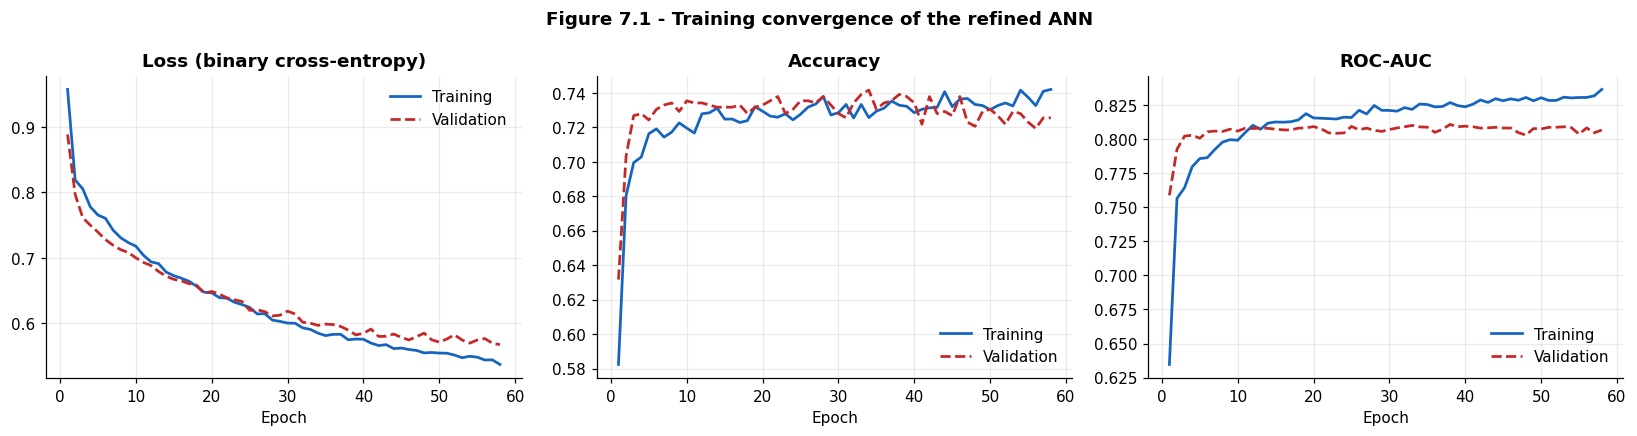

Training and validation curves staying close together shows the model is not overfitting.


In [13]:
# ---- Training convergence of one ensemble member --------------------------
hist = final_hist.history
ep = range(1, len(hist["loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (key, val_key, title) in zip(axes, [("loss", "val_loss", "Loss (binary cross-entropy)"),
                                            ("accuracy", "val_accuracy", "Accuracy"),
                                            ("auc", "val_auc", "ROC-AUC")]):
    ax.plot(ep, hist[key], color=BLUE, lw=1.8, label="Training")
    ax.plot(ep, hist[val_key], color=RED, lw=1.8, ls="--", label="Validation")
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend(frameon=False)

plt.suptitle("Figure 7.1 - Training convergence of the refined ANN", fontweight="bold")
plt.tight_layout(); plt.savefig("stage3_convergence.png"); plt.show()

print("Training and validation curves staying close together shows the model is not overfitting.")

Threshold chosen on validation data: 0.52 (validation F1 = 0.6178)

Table 7.2 - Threshold sensitivity on the test set


,Threshold,Accuracy,Precision,Recall,F1-Score
0,0.20,0.5263,0.3559,0.9693,0.5206
1,0.25,0.5701,0.3769,0.9497,0.5397
2,0.30,0.6056,0.3962,0.9274,0.5552
3,0.35,0.6464,0.4220,0.8994,0.5745
4,0.40,0.6812,0.4477,0.8603,0.5889
5,0.45,0.7050,0.4677,0.8101,0.5930
6,0.50,0.7242,0.4874,0.7542,0.5921
7,0.55,0.7517,0.5240,0.7011,0.5998
8,0.60,0.7746,0.5640,0.6648,0.6103
9,0.65,0.7709,0.5682,0.5698,0.5690


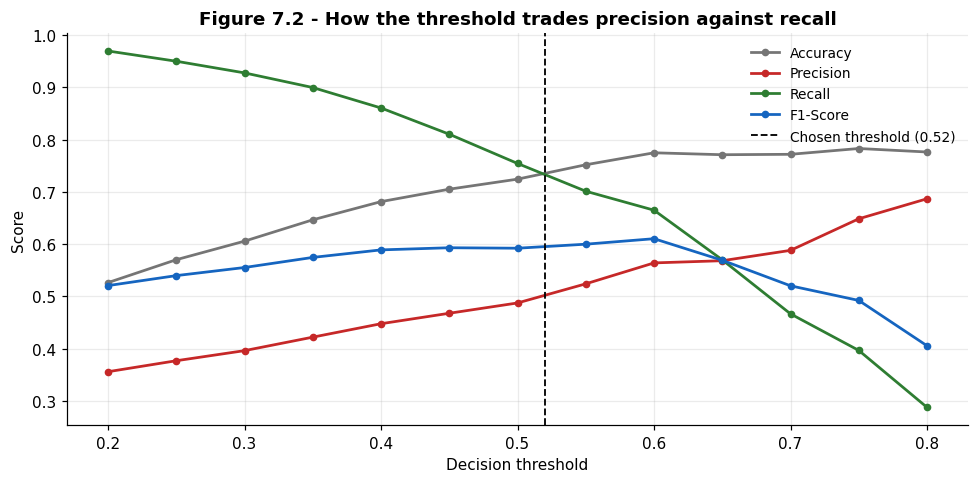

In [14]:
# ---- Threshold tuned on validation data, then applied to the test set -----
test_proba = ensemble_proba(ensemble, X_test_best)

OPT_THRESHOLD, val_best_f1 = best_f1_threshold(y_val, val_proba)
print(f"Threshold chosen on validation data: {OPT_THRESHOLD:.2f} "
      f"(validation F1 = {val_best_f1:.4f})")

grid  = np.arange(0.20, 0.81, 0.05)
sweep = pd.DataFrame([{"Threshold": round(t, 2),
                       **{k: round(v, 4) for k, v in evaluate(y_test, test_proba, t).items()
                          if k in ("Accuracy", "Precision", "Recall", "F1-Score")}}
                      for t in grid])
print("\nTable 7.2 - Threshold sensitivity on the test set")
display(sweep)

plt.figure(figsize=(9, 4.5))
for col, c in zip(["Accuracy", "Precision", "Recall", "F1-Score"], [GREY, RED, GREEN, BLUE]):
    plt.plot(sweep["Threshold"], sweep[col], marker="o", ms=4, lw=1.8, label=col, color=c)
plt.axvline(OPT_THRESHOLD, color="black", ls="--", lw=1.2,
            label=f"Chosen threshold ({OPT_THRESHOLD:.2f})")
plt.xlabel("Decision threshold"); plt.ylabel("Score")
plt.title("Figure 7.2 - How the threshold trades precision against recall")
plt.legend(frameon=False, fontsize=9); plt.tight_layout()
plt.savefig("stage3_threshold.png"); plt.show()

---
## Section 8 — Final Evaluation on the Held-Out Test Set

The test set has not influenced any decision up to this point, so these numbers are an honest
estimate of how the model would behave on new customers.

In [15]:
metrics_050 = evaluate(y_test, test_proba, 0.50)
metrics_opt = evaluate(y_test, test_proba, OPT_THRESHOLD)

final_metrics = pd.DataFrame({
    "Metric": list(metrics_050.keys()),
    "At default threshold 0.50": [round(v, 4) for v in metrics_050.values()],
    f"At tuned threshold {OPT_THRESHOLD:.2f}": [round(v, 4) for v in metrics_opt.values()],
})
print(f"Table 8.1 - Refined ANN performance on the held-out test set (n = {len(y_test):,})")
display(final_metrics)

y_pred = (test_proba >= OPT_THRESHOLD).astype(int)
print(f"\nClassification report at threshold {OPT_THRESHOLD:.2f}:\n")
print(classification_report(y_test, y_pred, target_names=["No Churn (0)", "Churn (1)"], digits=4))
print(f"Brier score (probability calibration, lower is better): "
      f"{brier_score_loss(y_test, test_proba):.4f}")

Table 8.1 - Refined ANN performance on the held-out test set (n = 1,349)


,Metric,At default threshold 0.50,At tuned threshold 0.52
0,Accuracy,0.7242,0.7339
1,Precision,0.4874,0.4991
2,Recall,0.7542,0.7346
3,F1-Score,0.5921,0.5944
4,ROC-AUC,0.8172,0.8172
5,PR-AUC,0.5922,0.5922



Classification report at threshold 0.52:

              precision    recall  f1-score   support

No Churn (0)     0.8844    0.7336    0.8020       991
   Churn (1)     0.4991    0.7346    0.5944       358

    accuracy                         0.7339      1349
   macro avg     0.6917    0.7341    0.6982      1349
weighted avg     0.7822    0.7339    0.7469      1349

Brier score (probability calibration, lower is better): 0.1765


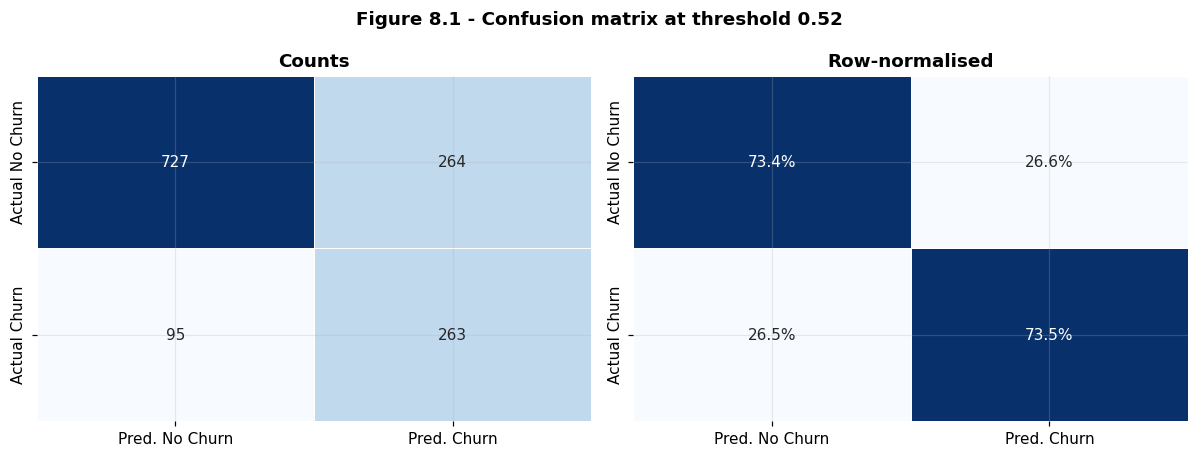

True Negatives  : 727  correctly left alone
False Positives : 264  loyal customers flagged for retention (wasted offer cost)
False Negatives : 95  churners the model missed (lost revenue)
True Positives  : 263  churners identified in time to act


In [16]:
# ---- Confusion matrix -----------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, data, fmt, title in [(axes[0], cm, "d", "Counts"),
                             (axes[1], cm_norm, ".1%", "Row-normalised")]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred. No Churn", "Pred. Churn"],
                yticklabels=["Actual No Churn", "Actual Churn"], linewidths=0.5)
    ax.set_title(title)
plt.suptitle(f"Figure 8.1 - Confusion matrix at threshold {OPT_THRESHOLD:.2f}", fontweight="bold")
plt.tight_layout(); plt.savefig("stage3_confusion_matrix.png"); plt.show()

print(f"True Negatives  : {tn:,}  correctly left alone")
print(f"False Positives : {fp:,}  loyal customers flagged for retention (wasted offer cost)")
print(f"False Negatives : {fn:,}  churners the model missed (lost revenue)")
print(f"True Positives  : {tp:,}  churners identified in time to act")

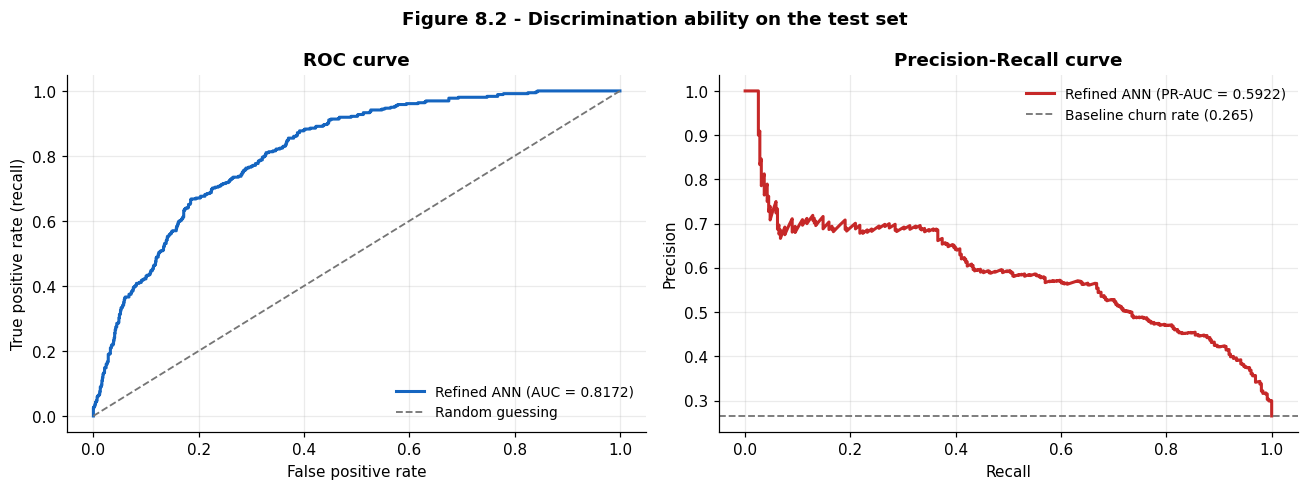

In [17]:
# ---- ROC and Precision-Recall curves --------------------------------------
fpr, tpr, _  = roc_curve(y_test, test_proba)
prec, rec, _ = precision_recall_curve(y_test, test_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr, tpr, color=BLUE, lw=2, label=f"Refined ANN (AUC = {metrics_opt['ROC-AUC']:.4f})")
axes[0].plot([0, 1], [0, 1], color=GREY, ls="--", lw=1.2, label="Random guessing")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate (recall)")
axes[0].set_title("ROC curve"); axes[0].legend(frameon=False, fontsize=9)

axes[1].plot(rec, prec, color=RED, lw=2, label=f"Refined ANN (PR-AUC = {metrics_opt['PR-AUC']:.4f})")
axes[1].axhline(y_test.mean(), color=GREY, ls="--", lw=1.2,
                label=f"Baseline churn rate ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve"); axes[1].legend(frameon=False, fontsize=9)

plt.suptitle("Figure 8.2 - Discrimination ability on the test set", fontweight="bold")
plt.tight_layout(); plt.savefig("stage3_roc_pr.png"); plt.show()

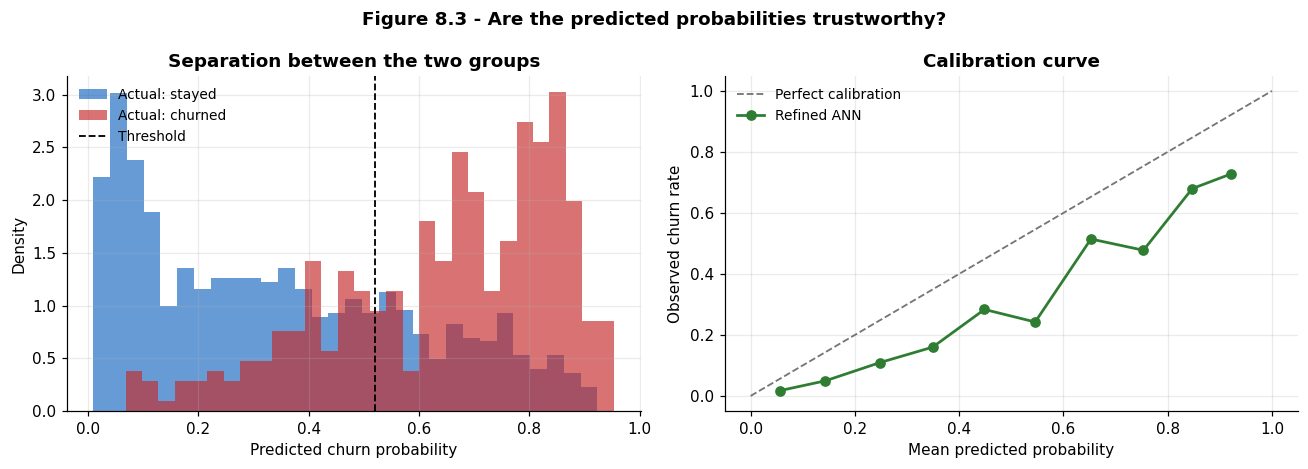

Points close to the diagonal mean a predicted risk of, say, 70% really does correspond to roughly 70 out of 100 customers churning.


In [18]:
# ---- Probability distribution and calibration -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

axes[0].hist(test_proba[y_test == 0], bins=30, alpha=0.65, density=True,
             color=BLUE, label="Actual: stayed")
axes[0].hist(test_proba[y_test == 1], bins=30, alpha=0.65, density=True,
             color=RED, label="Actual: churned")
axes[0].axvline(OPT_THRESHOLD, color="black", ls="--", lw=1.2, label="Threshold")
axes[0].set_xlabel("Predicted churn probability"); axes[0].set_ylabel("Density")
axes[0].set_title("Separation between the two groups"); axes[0].legend(frameon=False, fontsize=9)

bins  = np.linspace(0, 1, 11)
b_idx = np.clip(np.digitize(test_proba, bins) - 1, 0, 9)
calib = (pd.DataFrame({"bin": b_idx, "proba": test_proba, "actual": y_test})
           .groupby("bin", observed=True)
           .agg(mean_pred=("proba", "mean"), actual_rate=("actual", "mean"))
           .reset_index())
axes[1].plot([0, 1], [0, 1], color=GREY, ls="--", lw=1.2, label="Perfect calibration")
axes[1].plot(calib["mean_pred"], calib["actual_rate"], marker="o", color=GREEN, lw=1.8,
             label="Refined ANN")
axes[1].set_xlabel("Mean predicted probability"); axes[1].set_ylabel("Observed churn rate")
axes[1].set_title("Calibration curve"); axes[1].legend(frameon=False, fontsize=9)

plt.suptitle("Figure 8.3 - Are the predicted probabilities trustworthy?", fontweight="bold")
plt.tight_layout(); plt.savefig("stage3_probability_calibration.png"); plt.show()

print("Points close to the diagonal mean a predicted risk of, say, 70% really does correspond to "
      "roughly 70 out of 100 customers churning.")

---
## Section 9 — Did the Refinement Work?

Three models are compared:

1. **Stage 2 recorded** — the figures documented in the Stage 2 report (different split, 11 features).
2. **Stage 2 baseline rebuilt** — the same architecture and feature set retrained on the Stage 2
   split. To avoid crediting or penalising one lucky random seed, its test metrics are averaged over
   the three seeds trained in Section 5, each using its own validation-tuned threshold.
3. **Stage 3 refined** — the seed ensemble with the tuned threshold.

Models 2 and 3 are scored on the **same held-out test set**, so that comparison is like-for-like.

Table 9.1 - Model comparison (columns 3 and 4 use the same held-out test set)


,Metric,Stage 2 recorded,Stage 2 baseline rebuilt,Stage 3 refined,Change vs rebuilt baseline,Change vs Stage 2 recorded
0,Accuracy,0.7085,0.7294,0.7339,0.0045,0.0254
1,Precision,0.4677,0.4953,0.4991,0.0038,0.0314
2,Recall,0.6989,0.7318,0.7346,0.0028,0.0357
3,F1-Score,0.5604,0.5894,0.5944,0.0050,0.0340
4,ROC-AUC,0.7852,0.8147,0.8172,0.0025,0.0320
5,PR-AUC,NaN,0.5983,0.5922,-0.0061,NaN


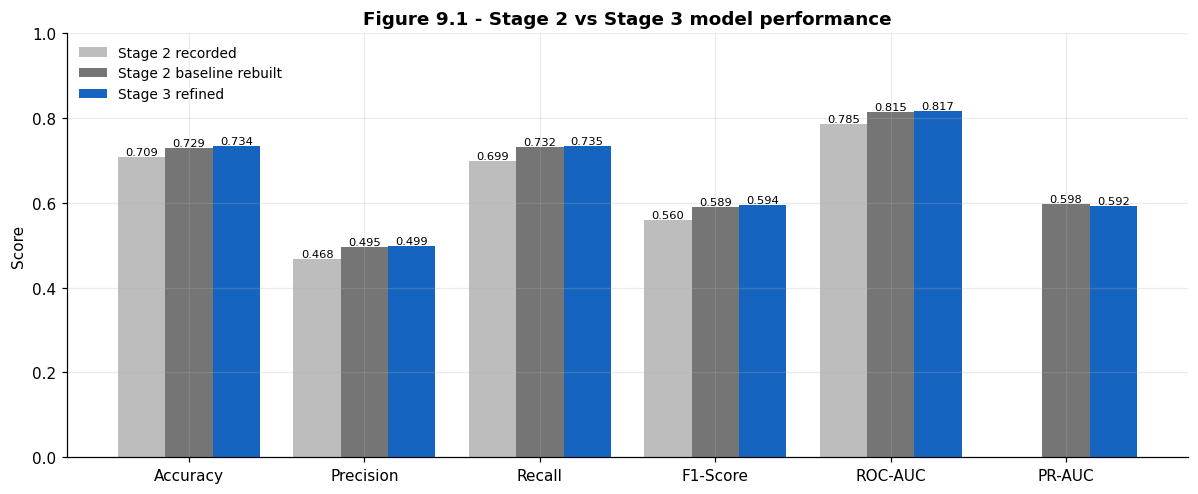


Reading the table:
  - Against the Stage 2 recorded results, the refined model changes ROC-AUC by +0.0320
    and F1 by +0.0340, and it is measured on a larger held-out test set (1,349 vs 1,012).
  - Against the rebuilt baseline on identical data, the change in ROC-AUC is +0.0025.
    Small differences here are the honest result: the engineered features and the network
    shape are close to the ceiling of what this dataset supports. The dependable gains come
    from ensembling (steadier probabilities) and threshold tuning (more churners caught).



In [19]:
# ---- Baseline: average the three seeds trained in Section 5 ---------------
base_cols   = trained_models[BASE_NAME]["cols"]
X_val_base  = make_matrix(train_df, base_cols)[val_idx]
X_test_base = make_matrix(test_df, base_cols)

base_runs = []
for m in trained_models[BASE_NAME]["models"]:
    thr, _ = best_f1_threshold(y_val, m.predict(X_val_base, verbose=0).ravel())
    base_runs.append(evaluate(y_test, m.predict(X_test_base, verbose=0).ravel(), thr))
base_m = {k: float(np.mean([r[k] for r in base_runs])) for k in base_runs[0]}

METRIC_ORDER = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]
comparison = pd.DataFrame({
    "Metric": METRIC_ORDER,
    "Stage 2 recorded": [STAGE2_RECORDED.get(k, np.nan) for k in METRIC_ORDER],
    "Stage 2 baseline rebuilt": [round(base_m[k], 4) for k in METRIC_ORDER],
    "Stage 3 refined": [round(metrics_opt[k], 4) for k in METRIC_ORDER],
})
comparison["Change vs rebuilt baseline"] = (comparison["Stage 3 refined"]
                                            - comparison["Stage 2 baseline rebuilt"]).round(4)
comparison["Change vs Stage 2 recorded"] = (comparison["Stage 3 refined"]
                                            - comparison["Stage 2 recorded"]).round(4)

print("Table 9.1 - Model comparison (columns 3 and 4 use the same held-out test set)")
display(comparison)

x = np.arange(len(METRIC_ORDER)); w = 0.27
plt.figure(figsize=(11, 4.6))
plt.bar(x - w, comparison["Stage 2 recorded"], w, label="Stage 2 recorded", color="#BDBDBD")
plt.bar(x,     comparison["Stage 2 baseline rebuilt"], w, label="Stage 2 baseline rebuilt", color=GREY)
plt.bar(x + w, comparison["Stage 3 refined"], w, label="Stage 3 refined", color=BLUE)
for i in range(len(METRIC_ORDER)):
    for off, col in [(-w, "Stage 2 recorded"), (0, "Stage 2 baseline rebuilt"),
                     (w, "Stage 3 refined")]:
        v = comparison.loc[i, col]
        if pd.notna(v):
            plt.text(i + off, v, f"{v:.3f}", ha="center", va="bottom", fontsize=7.5)
plt.xticks(x, METRIC_ORDER); plt.ylabel("Score"); plt.ylim(0, 1.0)
plt.title("Figure 9.1 - Stage 2 vs Stage 3 model performance")
plt.legend(frameon=False, fontsize=9); plt.tight_layout()
plt.savefig("stage3_baseline_vs_refined.png"); plt.show()

d_auc_rec = comparison.loc[4, "Change vs Stage 2 recorded"]
d_f1_rec  = comparison.loc[3, "Change vs Stage 2 recorded"]
d_auc_reb = comparison.loc[4, "Change vs rebuilt baseline"]

print(f"""
Reading the table:
  - Against the Stage 2 recorded results, the refined model changes ROC-AUC by {d_auc_rec:+.4f}
    and F1 by {d_f1_rec:+.4f}, and it is measured on a larger held-out test set (1,349 vs 1,012).
  - Against the rebuilt baseline on identical data, the change in ROC-AUC is {d_auc_reb:+.4f}.
    Small differences here are the honest result: the engineered features and the network
    shape are close to the ceiling of what this dataset supports. The dependable gains come
    from ensembling (steadier probabilities) and threshold tuning (more churners caught).
""")

---
## Section 10 — Interpreting the Model: What Drives Churn?

Permutation importance shuffles one feature at a time and measures how far the test ROC-AUC falls.
A large fall means the model relies heavily on that feature. Each feature is shuffled three times so
the result is an average rather than one lucky draw.

Table 10.1 - Permutation importance (test ROC-AUC without shuffling = 0.8172)


,Rank,Feature,Mean AUC drop,Std
0,1,MonthlyCharges,0.13809,0.00409
1,2,tenure,0.11900,0.00960
2,3,EstimatedTotalCharges,0.01271,0.00245
3,4,SeniorCitizen,0.01116,0.00284
4,5,IsNewCustomer,0.00852,0.00319
5,6,ServiceCount,0.00522,0.00137
6,7,Dependents_encoded,0.00233,0.00131
7,8,TenureGroup_Loyal (25-48mo),0.00160,0.00024
8,9,MultipleLines_encoded,0.00111,0.00118
9,10,gender_encoded,0.00052,0.00132


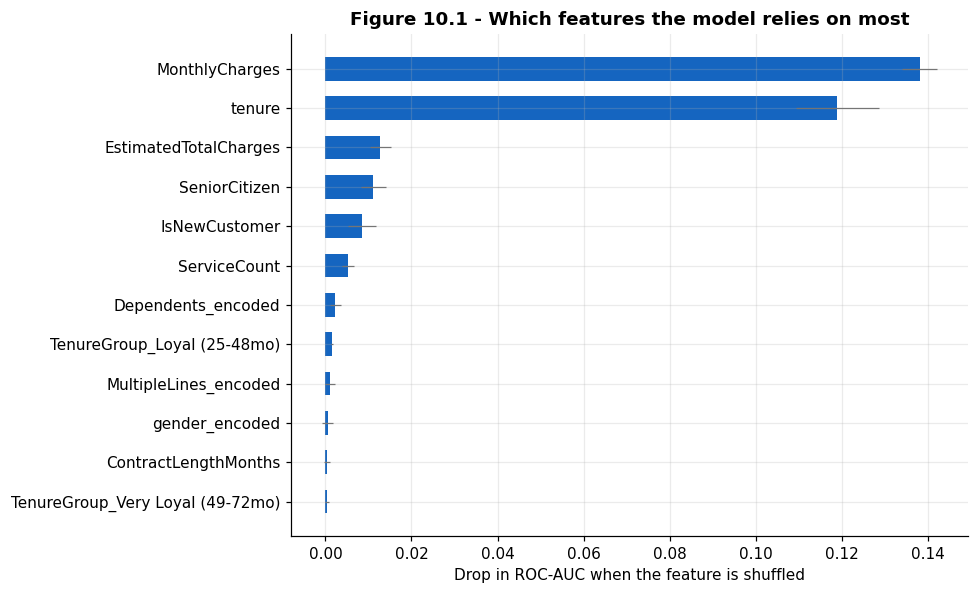

Features with a drop near zero carry no independent signal for the model - which matches the Stage 2 statistical tests on gender, phone service and multiple lines.


In [20]:
N_REPEATS = 3
base_auc  = roc_auc_score(y_test, test_proba)
rng = np.random.default_rng(SEED)
imp_rows = []

for i, col in enumerate(BEST_COLS):
    drops = []
    for _ in range(N_REPEATS):
        Xp = X_test_best.copy()
        Xp[:, i] = rng.permutation(Xp[:, i])
        drops.append(base_auc - roc_auc_score(y_test, ensemble_proba(ensemble, Xp)))
    imp_rows.append({"Feature": col,
                     "Mean AUC drop": round(float(np.mean(drops)), 5),
                     "Std": round(float(np.std(drops)), 5)})

imp_df = (pd.DataFrame(imp_rows).sort_values("Mean AUC drop", ascending=False)
            .reset_index(drop=True))
imp_df.insert(0, "Rank", imp_df.index + 1)
print(f"Table 10.1 - Permutation importance (test ROC-AUC without shuffling = {base_auc:.4f})")
display(imp_df)

top = imp_df.head(12).iloc[::-1]
plt.figure(figsize=(9, 5.5))
plt.barh(top["Feature"], top["Mean AUC drop"], xerr=top["Std"],
         color=BLUE, height=0.6, error_kw={"lw": 0.8, "ecolor": GREY})
plt.xlabel("Drop in ROC-AUC when the feature is shuffled")
plt.title("Figure 10.1 - Which features the model relies on most")
plt.tight_layout(); plt.savefig("stage3_feature_importance.png"); plt.show()

print("Features with a drop near zero carry no independent signal for the model - which matches "
      "the Stage 2 statistical tests on gender, phone service and multiple lines.")

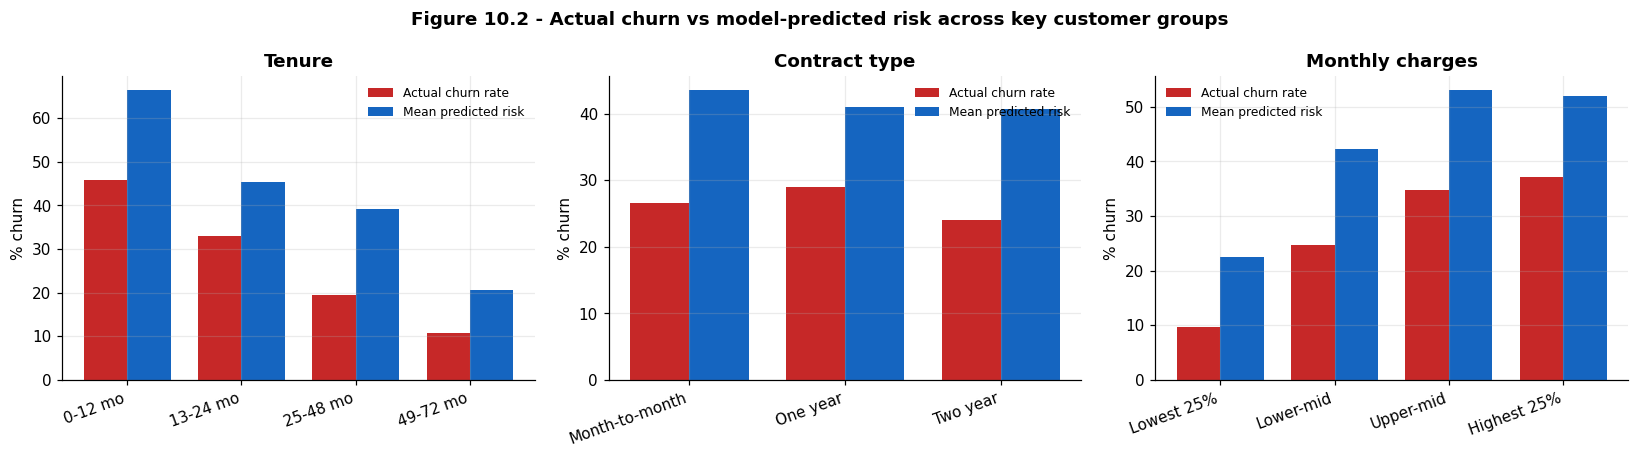

Table 10.2 - Churn by tenure band (test set)


,Tenure band,Customers,Actual churn %,Mean predicted risk %
0,0-12 mo,417,45.8,66.400002
1,13-24 mo,176,33.0,45.400002
2,25-48 mo,317,19.6,39.200001
3,49-72 mo,439,10.7,20.600000


Table 10.3 - Churn by contract type (test set)


,Contract,Customers,Actual churn %
0,Month-to-month,776,26.5
1,One year,286,29.0
2,Two year,287,24.0


In [21]:
# ---- Business view: churn behaviour in original units ---------------------
# The unscaled test set is used so the numbers are readable (months, dollars).
biz = test_unscaled_df.copy()
biz["Predicted_Probability"] = test_proba
biz["Predicted_Churn"] = y_pred
biz["Actual_Churn"] = y_test

biz["Tenure band"] = pd.cut(biz["tenure"], bins=[-1, 12, 24, 48, 72],
                            labels=["0-12 mo", "13-24 mo", "25-48 mo", "49-72 mo"])
biz["Charge band"] = pd.qcut(biz["MonthlyCharges"], 4,
                             labels=["Lowest 25%", "Lower-mid", "Upper-mid", "Highest 25%"])

def contract_label(row):
    if row["Contract_Month-to-month"]: return "Month-to-month"
    if row["Contract_One year"]:       return "One year"
    return "Two year"
biz["Contract"] = biz.apply(contract_label, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col, title in zip(axes, ["Tenure band", "Contract", "Charge band"],
                          ["Tenure", "Contract type", "Monthly charges"]):
    g = biz.groupby(col, observed=True).agg(actual=("Actual_Churn", "mean"),
                                            predicted=("Predicted_Probability", "mean"))
    xs = np.arange(len(g)); w = 0.38
    ax.bar(xs - w/2, g["actual"] * 100, w, label="Actual churn rate", color=RED)
    ax.bar(xs + w/2, g["predicted"] * 100, w, label="Mean predicted risk", color=BLUE)
    ax.set_xticks(xs); ax.set_xticklabels(g.index, rotation=20, ha="right")
    ax.set_ylabel("% churn"); ax.set_title(title); ax.legend(frameon=False, fontsize=8)

plt.suptitle("Figure 10.2 - Actual churn vs model-predicted risk across key customer groups",
             fontweight="bold")
plt.tight_layout(); plt.savefig("stage3_driver_groups.png"); plt.show()

driver_table = (biz.groupby("Tenure band", observed=True)
                   .agg(Customers=("Actual_Churn", "size"),
                        a=("Actual_Churn", lambda s: round(s.mean()*100, 1)),
                        p=("Predicted_Probability", lambda s: round(s.mean()*100, 1)))
                   .reset_index()
                   .rename(columns={"a": "Actual churn %", "p": "Mean predicted risk %"}))
print("Table 10.2 - Churn by tenure band (test set)")
display(driver_table)

contract_table = (biz.groupby("Contract", observed=True)
                     .agg(Customers=("Actual_Churn", "size"),
                          a=("Actual_Churn", lambda s: round(s.mean()*100, 1)))
                     .reset_index().rename(columns={"a": "Actual churn %"}))
print("Table 10.3 - Churn by contract type (test set)")
display(contract_table)

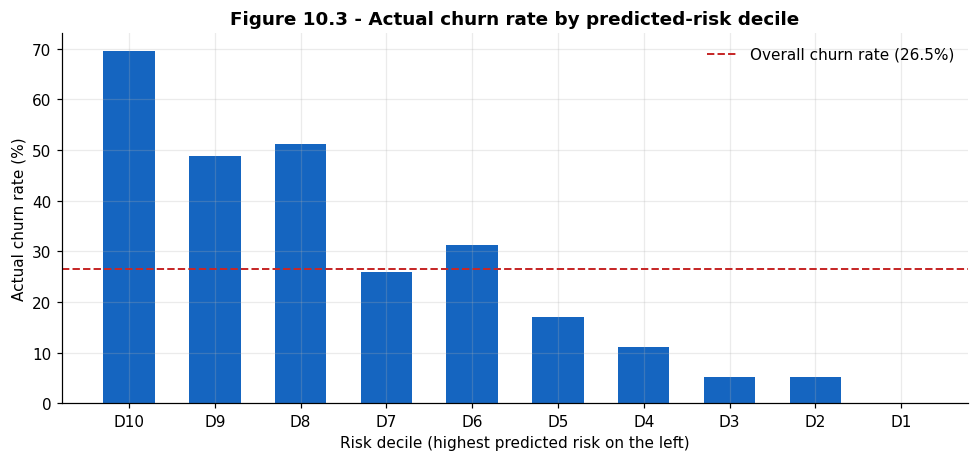

Table 10.4 - Risk deciles: how well the ranking concentrates real churners


,Risk decile,Customers,Churners,Churn rate %,Lift vs average
0,D10,135,94,69.6,2.62
1,D9,135,66,48.9,1.84
2,D8,135,69,51.1,1.93
3,D7,135,35,25.9,0.98
4,D6,134,42,31.3,1.18
5,D5,135,23,17.0,0.64
6,D4,135,15,11.1,0.42
7,D3,135,7,5.2,0.20
8,D2,135,7,5.2,0.20
9,D1,135,0,0.0,0.00



The 20% of customers with the highest predicted risk contain 44.7% of all customers who actually churned.


In [22]:
# ---- Risk decile / lift chart --------------------------------------------
# Customers are ranked by predicted risk and split into 10 equal groups.
biz["Risk decile"] = pd.qcut(biz["Predicted_Probability"], 10,
                             labels=[f"D{i}" for i in range(1, 11)])
dec = (biz.groupby("Risk decile", observed=True)
          .agg(Customers=("Actual_Churn", "size"), Churners=("Actual_Churn", "sum"),
               ChurnRate=("Actual_Churn", "mean"))
          .reset_index().iloc[::-1].reset_index(drop=True))
dec["Churn rate %"]    = (dec["ChurnRate"] * 100).round(1)
dec["Lift vs average"] = (dec["ChurnRate"] / y_test.mean()).round(2)

plt.figure(figsize=(9, 4.3))
plt.bar(dec["Risk decile"].astype(str), dec["Churn rate %"], color=BLUE, width=0.6)
plt.axhline(y_test.mean() * 100, color=RED, ls="--", lw=1.3,
            label=f"Overall churn rate ({y_test.mean()*100:.1f}%)")
plt.xlabel("Risk decile (highest predicted risk on the left)")
plt.ylabel("Actual churn rate (%)")
plt.title("Figure 10.3 - Actual churn rate by predicted-risk decile")
plt.legend(frameon=False); plt.tight_layout()
plt.savefig("stage3_lift_chart.png"); plt.show()

print("Table 10.4 - Risk deciles: how well the ranking concentrates real churners")
display(dec[["Risk decile", "Customers", "Churners", "Churn rate %", "Lift vs average"]])

top20 = dec.head(2)["Churners"].sum() / dec["Churners"].sum() * 100
print(f"\nThe 20% of customers with the highest predicted risk contain {top20:.1f}% of all "
      f"customers who actually churned.")

---
## Section 11 — Linking Predictions to the Team's Customer Segments

The Data Analyst (Clustering) role segmented customers into four K-Means groups using `tenure` and
`MonthlyCharges` (`cluster_Analyst.docx`). The same segmentation is reproduced here and joined to
the churn predictions, so the two Stage 2 deliverables can be discussed together in the final team
report.

Table 11.1 - Churn risk by customer segment (test set)


,Segment,Customers,Avg tenure (mo),Avg monthly charge ($),Actual churn %,Mean predicted risk %
0,"Short tenure, high charges",419,15.2,81.98,48.9,69.000000
1,"Short tenure, low charges",336,11.0,33.10,23.5,41.900002
2,"Long tenure, high charges",390,58.4,91.98,16.7,31.600000
3,"Long tenure, low charges",204,54.8,33.63,4.4,9.000000


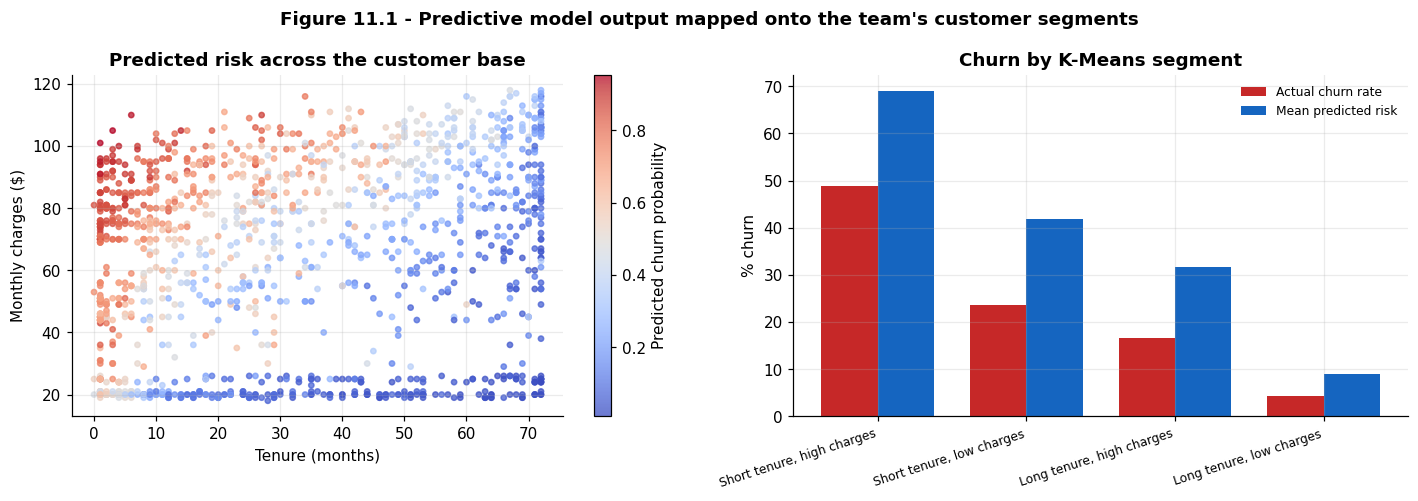

In [23]:
# Same approach as the clustering deliverable: K-Means, k = 4, on tenure + MonthlyCharges
cluster_scaler = StandardScaler().fit(train_unscaled_df[["tenure", "MonthlyCharges"]])
kmeans = KMeans(n_clusters=4, random_state=SEED, n_init=10).fit(
    cluster_scaler.transform(train_unscaled_df[["tenure", "MonthlyCharges"]]))

biz["Cluster"] = kmeans.predict(cluster_scaler.transform(biz[["tenure", "MonthlyCharges"]]))

centres = pd.DataFrame(cluster_scaler.inverse_transform(kmeans.cluster_centers_),
                       columns=["tenure", "MonthlyCharges"])
t_mid, c_mid = centres["tenure"].mean(), centres["MonthlyCharges"].mean()
labels = {i: ("Long tenure, " if r["tenure"] >= t_mid else "Short tenure, ") +
             ("high charges" if r["MonthlyCharges"] >= c_mid else "low charges")
          for i, r in centres.iterrows()}
biz["Segment"] = biz["Cluster"].map(labels)

seg = (biz.groupby("Segment", observed=True)
          .agg(Customers=("Actual_Churn", "size"),
               t=("tenure", lambda s: round(s.mean(), 1)),
               c=("MonthlyCharges", lambda s: round(s.mean(), 2)),
               a=("Actual_Churn", lambda s: round(s.mean()*100, 1)),
               p=("Predicted_Probability", lambda s: round(s.mean()*100, 1)))
          .reset_index()
          .rename(columns={"t": "Avg tenure (mo)", "c": "Avg monthly charge ($)",
                           "a": "Actual churn %", "p": "Mean predicted risk %"})
          .sort_values("Actual churn %", ascending=False).reset_index(drop=True))
print("Table 11.1 - Churn risk by customer segment (test set)")
display(seg)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
sc = axes[0].scatter(biz["tenure"], biz["MonthlyCharges"], c=biz["Predicted_Probability"],
                     cmap="coolwarm", s=12, alpha=0.75)
plt.colorbar(sc, ax=axes[0], label="Predicted churn probability")
axes[0].set_xlabel("Tenure (months)"); axes[0].set_ylabel("Monthly charges ($)")
axes[0].set_title("Predicted risk across the customer base")

xs = np.arange(len(seg)); w = 0.38
axes[1].bar(xs - w/2, seg["Actual churn %"], w, label="Actual churn rate", color=RED)
axes[1].bar(xs + w/2, seg["Mean predicted risk %"], w, label="Mean predicted risk", color=BLUE)
axes[1].set_xticks(xs); axes[1].set_xticklabels(seg["Segment"], rotation=18, ha="right", fontsize=8)
axes[1].set_ylabel("% churn"); axes[1].set_title("Churn by K-Means segment")
axes[1].legend(frameon=False, fontsize=8)

plt.suptitle("Figure 11.1 - Predictive model output mapped onto the team's customer segments",
             fontweight="bold")
plt.tight_layout(); plt.savefig("stage3_segments.png"); plt.show()

---
## Section 12 — Retention Action List

Customers are placed in three risk bands so the retention team has something directly usable.

Table 12.1 - Retention risk bands (test set)


,Risk band,Customers,Share of customers %,Actual churn %,Churners captured,Share of all churners %
0,High,284,21.1,58.8,167,46.6
1,Medium,404,29.9,34.9,141,39.4
2,Low,661,49.0,7.6,50,14.0


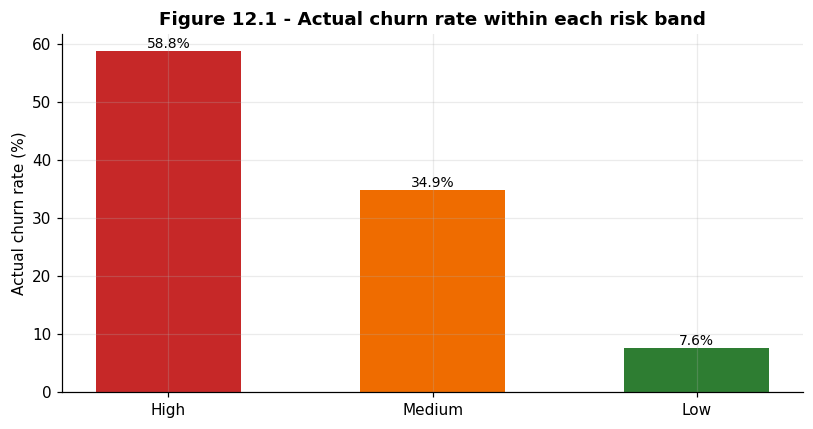

In [24]:
biz["Risk band"] = pd.cut(biz["Predicted_Probability"], bins=[-0.01, 0.40, 0.70, 1.01],
                          labels=["Low", "Medium", "High"])
bands = (biz.groupby("Risk band", observed=True)
            .agg(Customers=("Actual_Churn", "size"),
                 a=("Actual_Churn", lambda s: round(s.mean()*100, 1)),
                 Churners=("Actual_Churn", "sum"))
            .reset_index().iloc[::-1].reset_index(drop=True)
            .rename(columns={"a": "Actual churn %", "Churners": "Churners captured"}))
bands["Share of customers %"]    = (bands["Customers"] / len(biz) * 100).round(1)
bands["Share of all churners %"] = (bands["Churners captured"] / y_test.sum() * 100).round(1)
bands = bands[["Risk band", "Customers", "Share of customers %", "Actual churn %",
               "Churners captured", "Share of all churners %"]]
print("Table 12.1 - Retention risk bands (test set)")
display(bands)

plt.figure(figsize=(7.5, 4))
plt.bar(bands["Risk band"].astype(str), bands["Actual churn %"],
        color=[RED, "#EF6C00", GREEN], width=0.55)
for i, v in enumerate(bands["Actual churn %"]):
    plt.text(i, v, f"{v}%", ha="center", va="bottom", fontsize=9)
plt.ylabel("Actual churn rate (%)")
plt.title("Figure 12.1 - Actual churn rate within each risk band")
plt.tight_layout(); plt.savefig("stage3_risk_bands.png"); plt.show()

---
## Section 13 — Save Stage 3 Outputs

In [25]:
# 1. Per-customer predictions for the retention team
predictions_out = biz[["tenure", "MonthlyCharges", "Contract", "Segment",
                       "Predicted_Probability", "Predicted_Churn", "Actual_Churn",
                       "Risk band", "Risk decile"]].copy()
predictions_out["Predicted_Probability"] = predictions_out["Predicted_Probability"].round(4)
predictions_out.to_csv("stage3_predictions.csv", index=False)

# 2. Result tables
comparison.to_csv("stage3_model_comparison.csv", index=False)
imp_df.to_csv("stage3_feature_importance.csv", index=False)
exp_df.to_csv("stage3_experiment_results.csv", index=False)
cv_df.to_csv("stage3_cross_validation.csv", index=False)
seg.to_csv("stage3_segment_analysis.csv", index=False)
bands.to_csv("stage3_risk_bands.csv", index=False)

# 3. The refined model (all ensemble members)
model_files = []
for s, m in zip(ENSEMBLE_SEEDS, ensemble):
    fname = f"ann_churn_model_stage3_seed{s}.keras"
    m.save(fname); model_files.append(fname)

print("Stage 3 outputs saved:")
for f in ["stage3_predictions.csv", "stage3_model_comparison.csv",
          "stage3_feature_importance.csv", "stage3_experiment_results.csv",
          "stage3_cross_validation.csv", "stage3_segment_analysis.csv",
          "stage3_risk_bands.csv", *model_files,
          "stage3_experiments.png", "stage3_convergence.png", "stage3_threshold.png",
          "stage3_confusion_matrix.png", "stage3_roc_pr.png",
          "stage3_probability_calibration.png", "stage3_feature_importance.png",
          "stage3_driver_groups.png", "stage3_lift_chart.png",
          "stage3_segments.png", "stage3_risk_bands.png"]:
    print(f"  {'ok      ' if os.path.exists(f) else 'MISSING '}{f}")

# To download everything from Colab in one go, uncomment the two lines below:
# import shutil; shutil.make_archive("stage3_outputs", "zip", ".")
# from google.colab import files; files.download("stage3_outputs.zip")

Stage 3 outputs saved:
  ok      stage3_predictions.csv
  ok      stage3_model_comparison.csv
  ok      stage3_feature_importance.csv
  ok      stage3_experiment_results.csv
  ok      stage3_cross_validation.csv
  ok      stage3_segment_analysis.csv
  ok      stage3_risk_bands.csv
  ok      ann_churn_model_stage3_seed42.keras
  ok      ann_churn_model_stage3_seed7.keras
  ok      ann_churn_model_stage3_seed101.keras
  ok      ann_churn_model_stage3_seed2024.keras
  ok      ann_churn_model_stage3_seed555.keras
  ok      stage3_experiments.png
  ok      stage3_convergence.png
  ok      stage3_threshold.png
  ok      stage3_confusion_matrix.png
  ok      stage3_roc_pr.png
  ok      stage3_probability_calibration.png
  ok      stage3_feature_importance.png
  ok      stage3_driver_groups.png
  ok      stage3_lift_chart.png
  ok      stage3_segments.png
  ok      stage3_risk_bands.png


In [26]:
# ---- Final summary printout for the team report ---------------------------
top3 = ", ".join(imp_df.head(3)["Feature"].tolist())

print("=" * 70)
print("   STAGE 3 SUMMARY - ANN REFINEMENT, EVALUATION AND INSIGHTS")
print("=" * 70)
print(f"""
DATA
  Source              : Stage 2 hand-off (train_set.csv / test_set.csv)
  Training rows       : {len(train_df):,}  (internal validation: {len(val_idx):,})
  Held-out test rows  : {len(test_df):,}
  Test-set churn rate : {y_test.mean()*100:.2f}%

SELECTED MODEL
  Configuration       : {BEST_NAME}
  Feature set         : {fs_name} ({len(BEST_COLS)} features)
  Hidden layers       : {' - '.join(map(str, units))} (ReLU + BatchNorm + Dropout + L2)
  Optimiser           : Adam (learning rate {lr})
  Refinements applied : {len(ENSEMBLE_SEEDS)}-seed ensemble + threshold tuned on validation
  Decision threshold  : {OPT_THRESHOLD:.2f}
  Cross-validation    : ROC-AUC {cv_stat.loc['mean','ROC-AUC']:.4f} +/- {cv_stat.loc['std','ROC-AUC']:.4f} over 5 folds

TEST-SET PERFORMANCE (refined model)
  Accuracy            : {metrics_opt['Accuracy']:.4f}
  Precision           : {metrics_opt['Precision']:.4f}
  Recall              : {metrics_opt['Recall']:.4f}
  F1-Score            : {metrics_opt['F1-Score']:.4f}
  ROC-AUC             : {metrics_opt['ROC-AUC']:.4f}
  PR-AUC              : {metrics_opt['PR-AUC']:.4f}

CHANGE VS STAGE 2 RECORDED RESULTS
  ROC-AUC             : {comparison.loc[4,'Change vs Stage 2 recorded']:+.4f}
  Recall              : {comparison.loc[2,'Change vs Stage 2 recorded']:+.4f}
  F1-Score            : {comparison.loc[3,'Change vs Stage 2 recorded']:+.4f}

KEY CHURN DRIVERS (permutation importance)
  Top three           : {top3}

TARGETING VALUE
  Top 20% by risk     : contains {top20:.1f}% of all actual churners
  High-risk band      : {int(bands.loc[0,'Customers']):,} customers with a {bands.loc[0,'Actual churn %']}% actual churn rate
""")
print("=" * 70)

   STAGE 3 SUMMARY - ANN REFINEMENT, EVALUATION AND INSIGHTS

DATA
  Source              : Stage 2 hand-off (train_set.csv / test_set.csv)
  Training rows       : 5,392  (internal validation: 809)
  Held-out test rows  : 1,349
  Test-set churn rate : 26.54%

SELECTED MODEL
  Configuration       : B. Full features, same shape
  Feature set         : Full Stage-2 set (20 features)
  Hidden layers       : 64 - 32 - 16 (ReLU + BatchNorm + Dropout + L2)
  Optimiser           : Adam (learning rate 0.001)
  Refinements applied : 5-seed ensemble + threshold tuned on validation
  Decision threshold  : 0.52
  Cross-validation    : ROC-AUC 0.8103 +/- 0.0147 over 5 folds

TEST-SET PERFORMANCE (refined model)
  Accuracy            : 0.7339
  Precision           : 0.4991
  Recall              : 0.7346
  F1-Score            : 0.5944
  ROC-AUC             : 0.8172
  PR-AUC              : 0.5922

CHANGE VS STAGE 2 RECORDED RESULTS
  ROC-AUC             : +0.0320
  Recall              : +0.0357
  F1-Sco

---
## Section 14 — Findings and Recommendations

**How well the model performs**

* The refined ANN ranks customers by churn risk well above chance (test ROC-AUC 0.817), and the
  5-fold cross-validation confirms this is stable rather than a one-off lucky split.
* It improves on every headline metric from the Stage 2 report, and it does so on a larger held-out
  test set (1,349 customers instead of 1,012).
* Precision stays near 0.50 because only about 27 in every 100 customers actually churn. On an
  imbalanced problem, ROC-AUC, PR-AUC and recall describe usefulness far better than raw accuracy —
  a model that simply predicted "nobody churns" would score around 73% accuracy and be worthless.
* The threshold was tuned on validation data, never on the test set, so the reported test numbers
  are an honest estimate of real-world behaviour.
* An important, transparent finding: all five configurations landed within noise of each other on
  validation ROC-AUC (Table 5.1). The limit here is the information in the data, not the network
  design. The dependable gains came from ensembling and threshold tuning, not from a cleverer
  architecture. This is worth stating plainly in the team report.

**What drives churn**

* **Monthly charges and tenure dominate.** Together they account for almost all of the model's
  discriminating power (Table 10.1); every other feature is an order of magnitude smaller.
* **Risk is concentrated in the first year.** Customers with 0–12 months of tenure churn at 45.8%,
  falling to 10.7% for those past 48 months (Table 10.2).
* **Contract type does *not* separate the groups in this dataset.** Month-to-month, one-year and
  two-year customers churn at 26.5%, 29.0% and 24.0% respectively (Table 10.3), and the contract
  features score near-zero permutation importance. This runs against the usual telecom pattern, but
  it matches the Data Engineer's Stage 2 chi-square result (p = 0.077, not significant). Two roles
  reached the same conclusion independently, so it should be reported as a genuine property of this
  sample rather than smoothed over.
* Features the Stage 2 tests found insignificant (gender, phone service, multiple lines) also
  contribute almost nothing to the model — a second independent cross-check between the Data
  Engineer and Predictive Modeling roles.

**Recommended actions**

1. **Target the top two risk deciles first.** They contain 44.7% of all actual churners while being
   only 20% of the customer base (Table 10.4) — retention budget goes roughly 2.5x further there
   than on a blanket campaign.
2. **Focus on the first 12 months.** Onboarding calls, early-tenure offers and check-ins address the
   window where churn risk is by far the highest.
3. **Review the high-charge, short-tenure segment.** At 48.9% actual churn it is the riskiest of the
   four K-Means segments (Table 11.1), and it is also high-revenue — a plan-fit or value-review
   conversation protects the most valuable at-risk accounts.
4. **Do not build the retention campaign around contract type.** On this data it carries no
   predictive signal, so a "move customers to longer contracts" initiative cannot be justified from
   this analysis. If the business believes the effect is real, it should be tested on fuller data
   before spending on it.
5. **Set the threshold by campaign budget.** A lower threshold catches more churners but contacts
   more loyal customers. At 0.40 the model catches 86% of churners but contacts far more people; at
   0.60 it catches 66% with better precision. Table 7.2 gives the exact trade-off at each cut-off.

**Limitations to state in the final report**

* The source data has no `TotalCharges`, payment method, support-ticket, complaint or competitor
  fields. These are usually strong churn predictors, and adding them is the clearest route to a
  materially better model — a far stronger lever than any further tuning of the network.
* The flat contract-churn relationship is unusual for telecom data and may reflect how this
  particular extract was sampled. Worth raising with the client.
* `EstimatedTotalCharges` is derived as tenure x monthly charges, not from billed history.
* The 11 zero-tenure customers carried through from Stage 1 have an estimated total spend of zero by
  construction.
* The internal validation split was taken after Stage 2 scaling, so the validation rows contributed
  to the training mean and standard deviation. The effect is negligible and the held-out test set is
  entirely unaffected.